In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.patches import Ellipse, Circle
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from time import process_time
import pandas as pd
from collections import defaultdict
import os

In [7]:
def zero_tensor():
    return (torch.zeros(1), torch.zeros(1))

class KFAC():
    def __init__(self, model):
        self.model = model
        self.fisher = defaultdict(zero_tensor)
        self.layer_names = {module: name for name,
                            module in model.named_modules()}

    def save_data(self, module, input, output):
        if isinstance(module, nn.Linear):
            self.fisher[self.layer_names[module]] = (
                input[0].data, output.data)

    def compute_fisher(self):
        for module in self.model.modules():
            if isinstance(module, nn.Linear):
                x, y = self.fisher[self.layer_names[module]]
                # Since we've saved the data from the forward pass, we don't need gradients
                with torch.no_grad():
                    x = x - x.mean(0)
                    y = y - y.mean(0)
                    self.fisher[self.layer_names[module]] = x.t() @ x / \
                        x.size(0), y.t() @ y / y.size(0)

    def register_hooks(self):
        for module in self.model.modules():
            if isinstance(module, nn.Linear):
                module.register_forward_hook(self.save_data)


class BioLinear(nn.Module):

    def __init__(self, in_dim, out_dim, in_fold=1, out_fold=1):
        super(BioLinear, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.linear = nn.Linear(in_dim, out_dim)
        self.in_fold = in_fold
        self.out_fold = out_fold
        assert in_dim % in_fold == 0
        assert out_dim % out_fold == 0
        # compute in_cor, shape: (in_dim)
        in_dim_fold = int(in_dim/in_fold)
        out_dim_fold = int(out_dim/out_fold)
        self.in_coordinates = torch.tensor(list(np.linspace(
            1/(2*in_dim_fold), 1-1/(2*in_dim_fold), num=in_dim_fold))*in_fold, dtype=torch.float)
        self.out_coordinates = torch.tensor(list(np.linspace(
            1/(2*out_dim_fold), 1-1/(2*out_dim_fold), num=out_dim_fold))*out_fold, dtype=torch.float)
        self.input = None
        self.output = None

    def forward(self, x):
        self.input = x.clone()
        self.output = self.linear(x).clone()
        return self.output

class BioMLP(nn.Module):
    def __init__(self, prune_perc = 0.1, in_dim=2, out_dim=2, w=2, depth=2, ystar=0.2, weight_factor=2, topk=10, shp=None, token_embedding=False, embedding_size=None):
        super(BioMLP, self).__init__()
        if shp == None:
            shp = [in_dim] + [w]*(depth-1) + [out_dim]
            self.in_dim = in_dim
            self.out_dim = out_dim
            self.depth = depth

        else:
            self.in_dim = shp[0]
            self.out_dim = shp[-1]
            self.depth = len(shp) - 1

        linear_list = []
        for i in range(self.depth):
            if i == 0:
                # for modular addition
                # linear_list.append(BioLinear(shp[i], shp[i+1], in_fold=2))
                # for regression
                linear_list.append(BioLinear(shp[i], shp[i+1], in_fold=1))

            else:
                linear_list.append(BioLinear(shp[i], shp[i+1]))
        self.linears = nn.ModuleList(linear_list)

        if token_embedding == True:
            # embedding size: number of tokens * embedding dimension
            self.embedding = torch.nn.Parameter(
                torch.normal(0, 1, size=embedding_size))

        self.shp = shp
        # parameters for the bio-inspired trick
        self.l0 = ystar  # distance between two nearby layers
        self.A = weight_factor
        self.in_perm = torch.nn.Parameter(torch.tensor(
            np.arange(int(self.in_dim/self.linears[0].in_fold)), dtype=torch.float))
        # self.register_parameter(name='in_perm', param=torch.nn.Parameter(torch.tensor(np.arange(int(self.in_dim/self.linears[0].in_fold)), dtype=torch.float)))
        self.out_perm = torch.nn.Parameter(torch.tensor(
            np.arange(int(self.out_dim/self.linears[-1].out_fold)), dtype=torch.float))
        # self.register_parameter(name='out_perm', param=torch.nn.Parameter(torch.tensor(np.arange(int(self.out_dim/self.linears[-1].out_fold)), dtype=torch.float)))
        self.top_k = topk
        self.token_embedding = token_embedding
        self.n_parameters = sum(p.numel() for p in self.parameters())
        self.original_params = None

        # Fisher information
        self.kfac = KFAC(self)
        self.removed_nodes = {i: [] for i in range(len(shp))}
        self.count_pruned_nodes = {i: shp[i] for i in range(len(shp))}
        self.prune = prune_perc
        self.masks = [torch.ones_like(layer.linear.weight) for layer in self.linears]
        self.bias_masks = [torch.ones_like(layer.linear.bias) for layer in self.linears]

    def forward(self, x):
        shp = x.shape
        in_fold = self.linears[0].in_fold
        x = x.reshape(shp[0], in_fold, int(shp[1]/in_fold))
        x = x[:,:,self.in_perm.long()]
        x = x.reshape(shp[0], shp[1])
        f = torch.nn.SiLU()
        for i in range(self.depth-1):
            x = f(self.linears[i](x))
        x = self.linears[-1](x)
        
        out_perm_inv = torch.zeros(self.out_dim, dtype=torch.long)
        out_perm_inv[self.out_perm.long()] = torch.arange(self.out_dim)
        x = x[:,out_perm_inv]
        # x = x[:,self.out_perm]

        return x

    def get_linear_layers(self):
        return self.linears

    def get_cc(self, bias_penalize=True, no_penalize_last=False):
        cc = 0
        num_linear = len(self.linears)
        for i in range(num_linear):
            if i == num_linear - 1 and no_penalize_last:
                weight_factor = 0.
            else:
                weight_factor = self.A
            biolinear = self.linears[i]
            dist = torch.abs(biolinear.out_coordinates.unsqueeze(dim=1) - biolinear.in_coordinates.unsqueeze(dim=0))
            cc += torch.sum(torch.abs(biolinear.linear.weight)*(weight_factor*dist+self.l0))
            if bias_penalize == True:
                cc += torch.sum(torch.abs(biolinear.linear.bias)*(self.l0))
        if self.token_embedding:
            cc += torch.sum(torch.abs(self.embedding)*(self.l0))
        return cc

    def swap_weight(self, weights, j, k, swap_type="out"):
        with torch.no_grad():
            if swap_type == "in":
                temp = weights[:, j].clone()
                weights[:, j] = weights[:, k].clone()
                weights[:, k] = temp
            elif swap_type == "out":
                temp = weights[j].clone()
                weights[j] = weights[k].clone()
                weights[k] = temp
            else:
                raise Exception(
                    "Swap type {} is not recognized!".format(swap_type))

    def swap_bias(self, biases, j, k):
        
        with torch.no_grad():
            temp = biases[j].clone()
            biases[j] = biases[k].clone()
            biases[k] = temp

    def swap(self, i, j, k, permanent=False):
        # in the ith layer (of neurons), swap the jth and the kth neuron.
        # Note: n layers of weights means n+1 layers of neurons.
        # (incoming, outgoing) * weights + biases are swapped.
        if permanent:
            print("Layer {}: Node {} swapped {}".format(i, j, k))
        if (int(j) in self.removed_nodes[i]) or (int(k) in self.removed_nodes[i]):
            print("Unsuccessfull swap!")
            return
        linears = self.get_linear_layers()
        num_linear = len(linears)
        if i == 0:
            # input layer, only has outgoing weights; update in_perm
            weights = linears[i].linear.weight
            infold = linears[i].in_fold
            fold_dim = int(weights.shape[1]/infold)
            for l in range(infold):
                self.swap_weight(weights, j+fold_dim*l, k +
                                 fold_dim*l, swap_type="in")
            # change input_perm
            self.swap_bias(self.in_perm, j, k)
        elif i == num_linear:
            # output layer, only has incoming weights and biases; update out_perm
            weights = linears[i-1].linear.weight
            biases = linears[i-1].linear.bias
            self.swap_weight(weights, j, k, swap_type="out")
            self.swap_bias(biases, j, k)
            # change output_perm
            self.swap_bias(self.out_perm, j, k)
        else:
            # middle layer : (incoming, outgoing) * weights, and biases
            weights_in = linears[i-1].linear.weight
            weights_out = linears[i].linear.weight
            biases = linears[i-1].linear.bias
            self.swap_weight(weights_in, j, k, swap_type="out")
            self.swap_weight(weights_out, j, k, swap_type="in")
            self.swap_bias(biases, j, k)


    def get_top_id(self, i):
        linears = self.get_linear_layers()
        num_linear = len(linears)
        if i == 0:
            # input layer
            weights = linears[i].linear.weight
            score = torch.sum(torch.abs(weights), dim=0)
            in_fold = linears[0].in_fold
            # print(score.shape)
            score = torch.sum(score.reshape(
                in_fold, int(score.shape[0]/in_fold)), dim=0)
        elif i == num_linear:
            # output layer
            weights = linears[i-1].linear.weight
            score = torch.sum(torch.abs(weights), dim=1)
        else:
            weights_in = linears[i-1].linear.weight
            weights_out = linears[i].linear.weight
            score = torch.sum(torch.abs(weights_out), dim=0) + \
                torch.sum(torch.abs(weights_in), dim=1)
        # print(score.shape)
        top_index = torch.flip(torch.argsort(score), [0])
        return top_index.tolist()

    def relocate_ij(self, i, j):
        # In the ith layer (of neurons), relocate the jth neuron
        linears = self.get_linear_layers()
        num_linear = len(linears)
        if i < num_linear:
            num_neuron = int(
                linears[i].linear.weight.shape[1]/linears[i].in_fold)
        else:
            num_neuron = linears[i-1].linear.weight.shape[0]
        ccs = []
        cnt_swaps = 0
        for k in range(num_neuron):
            if ((j in self.removed_nodes[i])) or (k in self.removed_nodes[i]) or (j == k) :
                continue
            self.swap(i, j, k)
            ccs.append(self.get_cc())
            self.swap(i, j, k)
            cnt_swaps += 1
        k = torch.argmin(torch.stack(ccs))
        self.swap(i, j, k, permanent=True)

    def relocate_i(self, i):
        # Relocate neurons in the ith layer
        top_id = self.get_top_id(i)
        cnt = 0
        for j in top_id:
            if cnt >= self.top_k:
                break
            if j in self.removed_nodes[i]:
                #print(f"Neuron {j} in layer {i} has been pruned")
                continue
            self.relocate_ij(i, j)
            cnt += 1

    def relocate(self):
        # Relocate neurons in the whole model
        linears = self.get_linear_layers()
        num_linear = len(linears)
        print(self.removed_nodes)
        for i in range(num_linear+1):
            self.relocate_i(i)

    def compute_fisher_information(self, X_val):
        # Initialize the FIM
        total_fim = None
        num_samples = 0

        # Iterate over the validation set

        self.kfac.register_hooks()
        outputs = self.forward(X_val)
        # Compute the FIM for the current sample
        self.kfac.compute_fisher()
        # If this is the first sample, initialize the total FIM

        if total_fim is None:
            total_fim = self.kfac.fisher
        else:
            # Otherwise, add the current FIM to the total FIM
            for key in total_fim.keys():
                total_fim[key] = total_fim[key] + self.kfac.fisher[key]

        # Replace the current FIM with the averaged FIM
        self.kfac.fisher = total_fim

    def rank_nodes_by_importance(self):
        # Initialize a dictionary to store the importance of each node
        node_importance = {}

        # Iterate over the FIM
        n = len(self.kfac.fisher.items())
        for indx, (layer_name, (FIM_in, FIM_out)) in enumerate(self.kfac.fisher.items()):
            # Get the corresponding layer from the model
            layer = dict(self.named_modules())[layer_name]

            # Compute the L1 sum of weights for each neuron

            if indx == 0:
                l1_weights = layer.weight.abs().sum(dim=1)

                #importance_out = FIM_out.sum(dim=0) * l1_weights
                importance_out = l1_weights
                node_importance[list(self.kfac.fisher.keys())[1]] = importance_out
            elif indx == n - 1:
                l1_weights = layer.weight.abs().sum(dim=0)

                #node_importance[layer_name] = FIM_in.sum(dim=1) * l1_weights
                node_importance[layer_name] = l1_weights
            else:
                l1_weights = layer.weight.abs().sum(dim=0)

                #node_importance[layer_name] += FIM_in.sum(dim=1) * l1_weights
                node_importance[layer_name] += l1_weights

                l1_weights = layer.weight.abs().sum(dim=0)
                #node_importance[list(self.kfac.fisher.keys())[indx+1]] = FIM_out.sum(dim=0) * l1_weights
                node_importance[list(self.kfac.fisher.keys())[indx+1]] = l1_weights

        # Now node_importance contains the importance of each node in each layer
        # We can rank the nodes by their importance
        ranked_nodes = {layer_name: torch.argsort(importance, descending=True)
                        for layer_name, importance in node_importance.items()}

        return ranked_nodes
    
    def prune_model(self):
        """
        Prune the model by setting the least important nodes to zero.

        Args:
        model: The model to be pruned.
        ranked_nodes: A dictionary where the keys are layer names and the values are tensors of node indices, sorted by importance.
        prune_ratio: The proportion of least important nodes to prune.
        """
        # Iterate over the layers
        cnt = 0
        store_weight = None
        ranked_nodes = self.rank_nodes_by_importance()
        layer_names = list(self.linears)
        for indx, (layer_name, node_indices) in enumerate(ranked_nodes.items()):
            # Get the layer from the model
            layer = dict(self.named_modules())[layer_name]
            prev_layer = layer_names[indx]
            # Calculate the number of nodes to prune
            num_nodes_to_prune = int(np.ceil(self.count_pruned_nodes[indx+1] * self.prune))
            if self.count_pruned_nodes[indx+1]-num_nodes_to_prune < self.shp[indx+1]*self.prune:
                continue
            self.count_pruned_nodes[indx+1] -= num_nodes_to_prune
            # Get the indices of the nodes to prune
            nodes_to_prune = []
            cnt_chosen = 0
            for node in node_indices:
                if cnt_chosen >= num_nodes_to_prune:
                    break
                if node in self.removed_nodes[indx]:
                    continue
                nodes_to_prune.append(node.item())
                cnt_chosen += 1
            nodes_to_prune = torch.tensor(nodes_to_prune)
            # Prune the nodes
            self.masks[indx][nodes_to_prune, :] = 0
            self.masks[indx+1][:, nodes_to_prune] = 0
                
            prev_layer.linear.weight.data *= self.masks[indx]
            layer.weight.data *= self.masks[indx+1]

            # Prune the corresponding biases
            if indx+1 != len(self.linears) - 1:  # No bias for the last layer
                self.bias_masks[indx+1][nodes_to_prune] = 0
                layer.bias.data[nodes_to_prune] = 0
                self.linears[indx+1].linear.bias.data[nodes_to_prune] = 0

            for node in nodes_to_prune:
                self.remove_node(indx+1, int(node))

            #for key, _ in self.removed_nodes.items():
                #if key[0] == indx+1:
                #    print("-"*50)
                #    print(f"Max val of pruned neuron in layer {key[0]} number {key[1]}")
                #    print(torch.max(torch.abs(layer.weight.data[:, key[1]])))
                #    print(torch.max(torch.abs(self.linears[indx+1].linear.weight.data[:, key[1]])))

    def remove_node(self, i, j):
        # Call this method to remove a node
        self.removed_nodes[i].append(j)


In [6]:
# HYPERPARAMETERS FOR TRAINING
steps = 200000
lr = 0.002
swap_log = 200 # Swap every swap_log steps
prune_log = [2000, 5000, 10000] + list(range(11000, 20001, 1000)) # Prune every prune_log steps
prune_perc = 0.1 # Percentage to be pruned every prune_log epochs
prune_max = 0.1 # Minimum percentage to be pruned per hidden layer
prune_begin = 5000 # Begin pruning after X% of steps

# TRACK TRAINING
plot_log = 200
save_log = 100
log = 100

# HYPERPARAMETERS FOR MODEL
model_type = "l1_bimt"
shp = [2, 20, 20, 2] # Shape of the model
topk = 6 # Number of candidate nodes to relocate per layer
ystar = 0.2 # Distance between two nearby layers
weight_factor = 2 # Weight factor for the bio-inspired trick
lamb = 0.01 # Regularization parameter 

# HYPERPARAMETERS FOR DATASET
n_samples_train = 400
n_samples_test = 200
noise = 0.1
test_size = 0.2
val_size = 0.1 # Validation set used to perform Fisher Information Based pruning
seed = 2
np.random.seed(seed)
torch.manual_seed(seed)

In [5]:
# GENERATE DATASET
X, y = make_moons(n_samples=n_samples_train, noise=noise)
X = torch.tensor(X, dtype=torch.float, requires_grad=True)
y = torch.tensor(y, dtype=torch.long)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

X_test, y_test = make_moons(n_samples=n_samples_test, noise=noise)
X_test = torch.tensor(X_test, dtype=torch.float, requires_grad=True)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
def train_model(model_name):
    os.makedirs(f"results/{model_name}", exist_ok=True)
    os.makedirs(f"models/{model_name}", exist_ok=True)

    # INITIALIZE MODEL
    model = BioMLP(in_dim=shp[0], out_dim=shp[-1], w=max(shp), depth=len(shp)-1, ystar=ystar, weight_factor=weight_factor, topk=topk, shp=shp)

    # INITIALIZE OPTIMIZER
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0)
    CEL = nn.CrossEntropyLoss()

    res = [] # Store results
    start = process_time()
    for step in range(steps):
        # small lambda first, then large lambda, then small lambda
        if step == 5000:
            lamb = 0.01
    
        if step == 15000:
            lamb = 0.001

        optimizer.zero_grad()
        y_pred = model(X_train)


        # Compute accuracy
        acc = (torch.argmax(y_pred, dim=1) == y_train).float().mean()
        pred_test = model(X_test)
        loss_test = CEL(pred_test, y_test)
        acc_test = torch.mean((torch.argmax(pred_test, dim=1) == y_test).float())
        
        loss = CEL(y_pred, y_train)
        reg = model.get_cc()
        total_loss += lamb*reg
        total_loss.backward()

        for layer, mask, bias_mask in zip(model.linears, model.masks, model.bias_masks):
            layer.linear.weight.grad *= mask
    
            layer.linear.bias.grad *= bias_mask
        optimizer.step()

        if (step+1) % log == 0:
            print("step = %d | total loss: %.2e | train loss: %.2e | test loss %.2e | train acc : %.2f | test acc : %.2f | reg: %.2e " % (step, total_loss.detach(
            ).numpy(), loss.detach().numpy(), loss_test.detach().numpy(), acc.detach().numpy(), acc_test.detach().numpy(), reg.detach().numpy()))
            res.append([step, total_loss.detach().numpy(), loss.detach().numpy(), loss_test.detach(
            ).numpy(), acc.detach().numpy(), acc_test.detach().numpy(), reg.detach().numpy()])

        if (step+2) % save_log == 0:
            torch.save(model,
                       f"models/{model_type}/model_{step:05d}.pt")
        if (step+1) % swap_log == 0:
            # pass
            model.relocate()

        if (step+1) in prune_log:
            model.compute_fisher_information(X_val)
            model.prune_model()

        if (step+1) % plot_log == 0:
            plt.figure(figsize=(3, 7))

            plt.subplot(2, 1, 1)

            N = 2
            s = 1/(2*max(shp))
            for j in range(len(shp)):
                N = shp[j]
                for i in range(N):
                    if i in model.removed_nodes[j]:
                        c = "red"
                    else:
                        c = "black"
                    circle = Ellipse((1/(2*N)+i/N, 0.1*j), s, s /
                                     10*((len(shp)-1)+0.4), color=c)
                    plt.gca().add_patch(circle)

            plt.ylim(-0.02, 0.1*(len(shp)-1)+0.02)
            plt.xlim(-0.02, 1.02)

            ii = 0
            for p in model.parameters():
                if len(p.shape) == 2:
                    p_shp = p.shape
                    p = p/torch.abs(p).max()
                    for i in range(p_shp[0]):
                        for j in range(p_shp[1]):
                            if p[i, j] > 0:
                                plt.plot([1/(2*p_shp[0])+i/p_shp[0], 1/(2*p_shp[1])+j/p_shp[1]], [
                                         0.1*(ii+1), 0.1*ii], lw=1*np.abs(p[i, j].detach().numpy()), color="blue")
                            else:
                                plt.plot([1/(2*p_shp[0])+i/p_shp[0], 1/(2*p_shp[1])+j/p_shp[1]], [
                                         0.1*(ii+1), 0.1*ii], lw=1*np.abs(p[i, j].detach().numpy()), color="red")

                    formulas = ["Class 1", "Class 2"]
                    if ii == 0:
                        for j in range(p_shp[1]):
                            plt.text(1/(2*p_shp[1])+j/p_shp[1]-0.05, 0.1*ii-0.04,
                                     "$x_{}$".format(model.in_perm[j].long()+1), fontsize=15)
                    ii += 1

            for j in range(p_shp[0]):
                plt.text(1/(2*p_shp[0])+j/p_shp[0]-0.15, 0.1*ii+0.02,
                         formulas[model.out_perm[j].long()], fontsize=15)

            plt.gca().axis('off')
            plt.title("step={}".format(step), fontsize=15, y=1.1)

            plt.subplot(2, 1, 2)

            start_x = X[:, 0].min()-0.1
            end_x = X[:, 0].max()+0.1
            start_y = X[:, 1].min()-0.1
            end_y = X[:, 1].max()+0.1
            n_values = 30

            x_vals = np.linspace(start_x.detach().numpy(),
                                 end_x.detach().numpy(), n_values)
            y_vals = np.linspace(start_y.detach().numpy(),
                                 end_y.detach().numpy(), n_values)
            XX, YY = np.meshgrid(x_vals, y_vals)
            pred = model(torch.tensor(
                [XX.reshape(-1,), YY.reshape(-1,)], dtype=torch.float).permute(1, 0))
            pred = pred[:, 1] - pred[:, 0]

            # ZZ = np.sqrt(XX**2 + YY**2)

            cp = plt.contourf(XX, YY, pred.reshape(n_values, n_values).detach(
            ).numpy(), [-100, 0., 100.], colors=["green", "orange"], alpha=0.2)
            # plt.colorbar(cp)
            color = ['green', 'orange']

            for i in range(n_samples_train):
                plt.scatter(X[i, 0].detach().numpy(),
                            X[i, 1].detach().numpy(), color=color[y[i]])

            plt.xticks([])
            plt.yticks([])
            plt.xlabel(r"$x_1$", fontsize=15)
            plt.ylabel(r"$x_2$", fontsize=15)
            # plt.show()

            plt.savefig(f"results/{model_type}/{step:05d}.jpg")


    pd.DataFrame(res, columns=["step", "total loss", "train loss", "test loss", "train acc",
                 "test acc", "reg"]).to_csv(f"logs/{model_type}_log.csv", index=False)

    end = process_time()
    print("Time elapsed: ", end-start)



step = 99 | total loss: 3.10e-01 | train loss: 2.59e-01 | test loss 2.80e-01 | train acc : 0.89 | test acc : 0.87 | reg: 5.12e+01 
step = 199 | total loss: 2.93e-01 | train loss: 2.50e-01 | test loss 2.76e-01 | train acc : 0.89 | test acc : 0.87 | reg: 4.23e+01 
{0: [], 1: [], 2: [], 3: []}
Layer 0: Node 1 swapped 0
Layer 0: Node 0 swapped 0
Layer 1: Node 5 swapped 5
Layer 1: Node 7 swapped 6
Layer 1: Node 8 swapped 7
Layer 1: Node 14 swapped 12
Layer 1: Node 13 swapped 11
Layer 1: Node 15 swapped 13
Layer 2: Node 10 swapped 11
Layer 2: Node 12 swapped 9
Layer 2: Node 3 swapped 5
Layer 2: Node 14 swapped 15
Layer 2: Node 17 swapped 10
Layer 2: Node 16 swapped 12
Layer 3: Node 1 swapped 0
Layer 3: Node 0 swapped 0
step = 299 | total loss: 2.81e-01 | train loss: 2.47e-01 | test loss 2.73e-01 | train acc : 0.89 | test acc : 0.87 | reg: 3.45e+01 
step = 399 | total loss: 2.37e-01 | train loss: 2.04e-01 | test loss 2.28e-01 | train acc : 0.91 | test acc : 0.89 | reg: 3.35e+01 
{0: [], 1: []

/var/folders/b_/x8lg97sd7512c9qf07myy77m0000gn/T/ipykernel_62162/3048311518.py:62: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(3, 7))


step = 10599 | total loss: 6.97e-01 | train loss: 6.93e-01 | test loss 6.93e-01 | train acc : 0.50 | test acc : 0.50 | reg: 3.37e-01 
{0: [], 1: [7, 11, 5, 12, 8, 4, 13, 3, 10, 14, 2, 15, 16, 18, 18], 2: [6, 4, 15, 8, 2, 10, 9, 14, 16, 9, 16, 17, 17, 19, 19], 3: []}
Layer 0: Node 1 swapped 0
Layer 0: Node 0 swapped 0
Layer 1: Node 0 swapped 0
Layer 1: Node 9 swapped 4
Unsuccessfull swap!
Layer 1: Node 19 swapped 2
Unsuccessfull swap!
Layer 1: Node 6 swapped 4
Unsuccessfull swap!
Layer 1: Node 1 swapped 4
Unsuccessfull swap!
Layer 1: Node 17 swapped 4
Unsuccessfull swap!
Layer 2: Node 1 swapped 5
Layer 2: Node 3 swapped 2
Unsuccessfull swap!
Layer 2: Node 18 swapped 1
Layer 2: Node 7 swapped 5
Layer 2: Node 12 swapped 3
Layer 2: Node 13 swapped 3
Layer 3: Node 1 swapped 0
Layer 3: Node 0 swapped 0
step = 10699 | total loss: 6.96e-01 | train loss: 6.93e-01 | test loss 6.93e-01 | train acc : 0.50 | test acc : 0.50 | reg: 3.35e-01 
step = 10799 | total loss: 6.96e-01 | train loss: 6.93e-01

KeyboardInterrupt: 

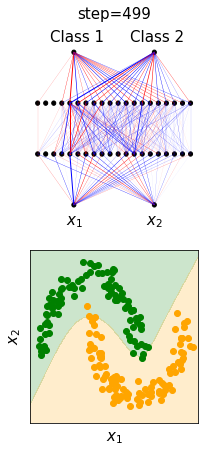

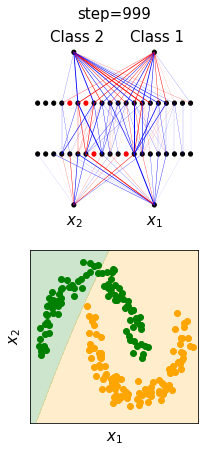

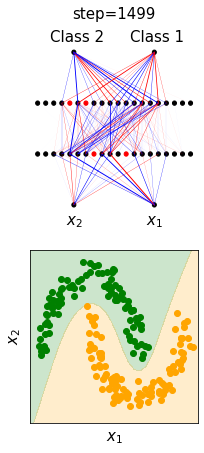

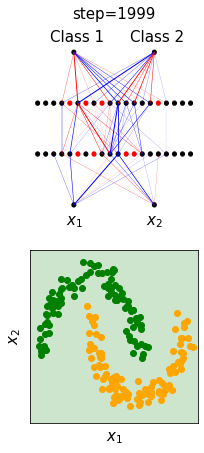

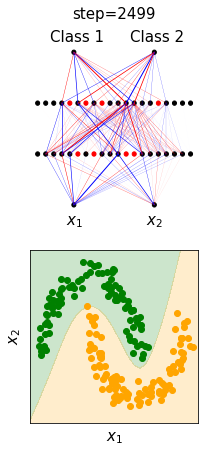

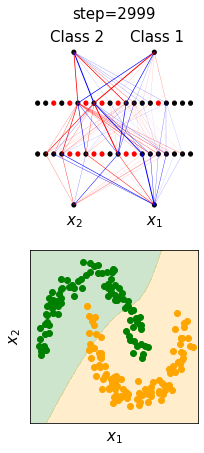

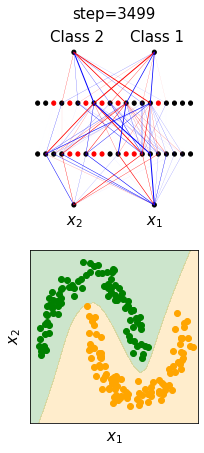

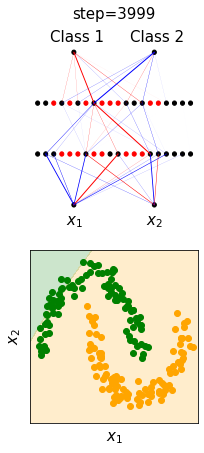

In [61]:
steps = 20000
plot_log = 500  # 50
save_log = 100
fisher_log = 1000
swap_log = 200
log = 100
cnt_prune = 0
max_prune = 15
start = process_time()

res = []
for step in range(steps):

    # small lambda first, then large lambda, then small lambda
    if step == 5000:
        lamb = 0.01

    if step == 15000:
        lamb = 0.001

    CEL = nn.CrossEntropyLoss()

    optimizer.zero_grad()
    pred = model(X)
    loss = CEL(pred, y)
    # print((torch.argmax(pred, dim=1) == y).float())
    acc = torch.mean((torch.argmax(pred, dim=1) == y).float())

    pred_test = model(X_test)
    loss_test = CEL(pred_test, y_test)
    acc_test = torch.mean((torch.argmax(pred_test, dim=1) == y_test).float())

    reg = model.get_cc()
    total_loss = loss + lamb*reg
    total_loss.backward()

    for layer, mask, bias_mask in zip(model.linears, model.masks, model.bias_masks):
        layer.linear.weight.grad *= mask

        layer.linear.bias.grad *= bias_mask
    optimizer.step()

    if (step+1) % log == 0:
        print("step = %d | total loss: %.2e | train loss: %.2e | test loss %.2e | train acc : %.2f | test acc : %.2f | reg: %.2e " % (step, total_loss.detach(
        ).numpy(), loss.detach().numpy(), loss_test.detach().numpy(), acc.detach().numpy(), acc_test.detach().numpy(), reg.detach().numpy()))
        res.append([step, total_loss.detach().numpy(), loss.detach().numpy(), loss_test.detach(
        ).numpy(), acc.detach().numpy(), acc_test.detach().numpy(), reg.detach().numpy()])
        
    if (step+2) % save_log == 0:
        torch.save(model,
                   f"models/{model_type}/model_{step:05d}.pt")
    if (step+1) % swap_log == 0:
        # pass
        model.relocate()
        
    if (step+1) % fisher_log == 0 and (cnt_prune < max_prune):
        model.compute_fisher_information(X_val)
        model.prune_model()
        cnt_prune += 1
        
    if (step+1) % plot_log == 0:
        plt.figure(figsize=(3, 7))

        plt.subplot(2, 1, 1)

        N = 2
        s = 1/(2*max(shp))
        for j in range(len(shp)):
            N = shp[j]
            for i in range(N):
                if i in model.removed_nodes[j]:
                    c = "red"
                else:
                    c = "black"
                circle = Ellipse((1/(2*N)+i/N, 0.1*j), s, s /
                                 10*((len(shp)-1)+0.4), color=c)
                plt.gca().add_patch(circle)

        plt.ylim(-0.02, 0.1*(len(shp)-1)+0.02)
        plt.xlim(-0.02, 1.02)

        ii = 0
        for p in model.parameters():
            if len(p.shape) == 2:
                p_shp = p.shape
                p = p/torch.abs(p).max()
                for i in range(p_shp[0]):
                    for j in range(p_shp[1]):
                        if p[i, j] > 0:
                            plt.plot([1/(2*p_shp[0])+i/p_shp[0], 1/(2*p_shp[1])+j/p_shp[1]], [
                                     0.1*(ii+1), 0.1*ii], lw=1*np.abs(p[i, j].detach().numpy()), color="blue")
                        else:
                            plt.plot([1/(2*p_shp[0])+i/p_shp[0], 1/(2*p_shp[1])+j/p_shp[1]], [
                                     0.1*(ii+1), 0.1*ii], lw=1*np.abs(p[i, j].detach().numpy()), color="red")

                formulas = ["Class 1", "Class 2"]
                if ii == 0:
                    for j in range(p_shp[1]):
                        plt.text(1/(2*p_shp[1])+j/p_shp[1]-0.05, 0.1*ii-0.04,
                                 "$x_{}$".format(model.in_perm[j].long()+1), fontsize=15)
                ii += 1

        for j in range(p_shp[0]):
            plt.text(1/(2*p_shp[0])+j/p_shp[0]-0.15, 0.1*ii+0.02,
                     formulas[model.out_perm[j].long()], fontsize=15)

        plt.gca().axis('off')
        plt.title("step={}".format(step), fontsize=15, y=1.1)

        plt.subplot(2, 1, 2)

        start_x = X[:, 0].min()-0.1
        end_x = X[:, 0].max()+0.1
        start_y = X[:, 1].min()-0.1
        end_y = X[:, 1].max()+0.1
        n_values = 30

        x_vals = np.linspace(start_x.detach().numpy(),
                             end_x.detach().numpy(), n_values)
        y_vals = np.linspace(start_y.detach().numpy(),
                             end_y.detach().numpy(), n_values)
        XX, YY = np.meshgrid(x_vals, y_vals)
        pred = model(torch.tensor(
            [XX.reshape(-1,), YY.reshape(-1,)], dtype=torch.float).permute(1, 0))
        pred = pred[:, 1] - pred[:, 0]

        # ZZ = np.sqrt(XX**2 + YY**2)

        cp = plt.contourf(XX, YY, pred.reshape(n_values, n_values).detach(
        ).numpy(), [-100, 0., 100.], colors=["green", "orange"], alpha=0.2)
        # plt.colorbar(cp)
        color = ['green', 'orange']

        for i in range(n_sample):
            plt.scatter(X[i, 0].detach().numpy(),
                        X[i, 1].detach().numpy(), color=color[y[i]])

        plt.xticks([])
        plt.yticks([])
        plt.xlabel(r"$x_1$", fontsize=15)
        plt.ylabel(r"$x_2$", fontsize=15)
        # plt.show()

        plt.savefig(f"results/{model_type}/{step:05d}.jpg")


pd.DataFrame(res, columns=["step", "total loss", "train loss", "test loss", "train acc",
             "test acc", "reg"]).to_csv(f"logs/{model_type}_log.csv", index=False)

end = process_time()
print("Time elapsed: ", end-start)


In [ ]:
a = torch.tensor([1, 2, 3]).tolist()
print(a)

[1, 2, 3]


In [ ]:
test_dict = {(1,2): True, (2,3): False}
print(a[1])
print((a[1].item(),3) in test_dict.keys())

tensor(2)
True


In [37]:
model = BioMLP(shp=[2,20,20,2], ystar=0.1, topk=6, weight_factor=2)
model = torch.load("models/l1_bimt/model_02998.pt")

print(model.linears[0].linear.weight.data)
print(model.removed_nodes)



tensor([[ 3.3970e-02, -2.1227e-04],
        [-9.2538e-06, -5.9060e-05],
        [-3.2064e-01,  1.0105e+00],
        [ 3.8650e-01, -1.6590e-01],
        [ 0.0000e+00,  0.0000e+00],
        [-0.0000e+00,  0.0000e+00],
        [ 0.0000e+00, -0.0000e+00],
        [-3.6189e-01,  1.6975e+00],
        [ 5.3397e-01,  1.2257e+00],
        [-6.0511e-06, -1.5857e-05],
        [ 2.2955e-01, -1.2651e+00],
        [-5.7046e-03, -4.7409e-01],
        [-2.4812e-05, -4.7369e-06],
        [ 8.0816e-07,  6.3077e-06],
        [ 1.4341e-05,  5.7051e-06],
        [ 0.0000e+00, -0.0000e+00],
        [-8.6015e-06,  5.4575e-02],
        [-1.9490e-05, -3.5819e-01],
        [ 4.0087e-01, -3.0981e-01],
        [ 2.5026e-04, -1.4257e-04]])
{(1, 5): True, (1, 6): True, (2, 7): True, (2, 11): True, (1, 4): True, (1, 15): True, (2, 5): True, (2, 4): True}


In [ ]:
def test_pruned_nodes_have_zero_weights_and_biases(model):
    for indx, layer in enumerate(model.linears):
        print(layer.linear.weight)
        for node in range(layer.linear.weight.shape[1]):
            if (indx+1, node) in model.removed_nodes:
                assert torch.all(layer.linear.weight[:, node] == 0), f"Pruned node {node} in layer {indx+1} has non-zero weights"
                if indx+1 != len(model.linears) - 1:  # No bias for the last layer
                    assert layer.linear.bias[node] == 0, f"Pruned node {node} in layer {indx+1} has non-zero bias"

In [ ]:
print(model.removed_nodes)

{}
